Alunos: Caio Moreira Bovo da Cunha Gomes (202505969) e Felipe Rodrigues de Sousa (202504000)

# Tirando sinais digitais - $x[n]$ ... pra fora do computador - $x(t)$!

Neste Notebook iremos trabalhar em como:
1. Criar um sinal `osc`, com frequência e duração controladas.
2. Sintetizar um sinal ***periódico e aleatório***, com frequência e duração controladas.
3. Plotar sinais em amostras, $x[n]$, tempo, $x(t)$, e frequência, $\mathcal{X}(\omega)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys

In [3]:
try:
    from google.colab import drive

    drive.mount('/content/drive')
    sys.path.append('/content/drive/MyDrive/UFG/01_teaching/')

except:
    # sys.path.append('/home/kuntur/Documents') # laptop version
    sys.path.append('/media/sdcard/Documents/') # tablet version

In [4]:

from IPython.display import Audio, display


def play(x, fs):
    '''
    Reproduz o sinal x[n] como audio, com frequencia de amostragem fs (Hz)
    '''
    display(Audio(data=x, rate=fs))


def SIGNALgenerate(signal='delta', N=100, k=0, A=1.0, P=100, phi=0.0, a=0.8, dist='gaussian'):
    '''
    Primitiva de geracao de sinais digitais (sem fs)

    signal: 'delta', 'step', 'exp', 'osc' ou 'random'
    N     : Numero de amostras
    k     : Atraso (delta e step)
    A     : Amplitude (osc)
    P     : Periodo em amostras (osc) -- pode ser nao inteiro
    phi   : Fase em rad (osc)
    a     : Coeficiente da exponencial (exp)
    dist  : 'gaussian' ou 'uniform' (random)

    x     : Sinal de saida
    n     : Vetor de amostras
    '''
    n = np.arange(N)

    if signal == 'delta':
        x = np.zeros(N)
        x[k] = 1.0
    elif signal == 'step':
        x = np.zeros(N)
        x[n >= k] = 1.0
    elif signal == 'exp':
        x = a ** n
    elif signal == 'osc':
        w0 = 2 * np.pi / P      # frequencia digital (rad/amostra)
        x = A * np.sin(w0 * n + phi)
    elif signal == 'random':
        if dist == 'uniform':
            x = np.random.uniform(-1, 1, N)
        else:
            x = np.random.randn(N)
    else:
        raise ValueError(f'Sinal desconhecido: {signal}')

    return x, n


def SIGNALplot(x, n=None, xlim=None, ylim=None, title=None, xlabel=None):
    '''
    Plota o sinal x contra o eixo n (amostras, tempo ou frequencia).
    Usa stem para poucas amostras visiveis e linha continua para muitas.
    '''
    x = np.asarray(x)
    n = np.arange(len(x)) if n is None else np.asarray(n)

    visible = len(x)
    if xlim is not None:
        visible = np.count_nonzero((n >= xlim[0]) & (n <= xlim[1]))

    fig, ax = plt.subplots(figsize=(10, 3.5))
    if visible <= 300:
        ax.stem(n, x, linefmt='r-', markerfmt='ro', basefmt='k-')
    else:
        ax.plot(n, x, 'r')

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

Complete a função `create_sine_signal`, que permite criar um **sinal oscilatório** (*le03, p. 24*):

$$
\Large
x[n] = A \, \sin\left(\omega_{0} \, n + \phi\right) = A \, \sin\left(\frac{2 \pi}{P} \, n + \phi\right)
$$

controlado pela sua:

- ***frequência*** $(f)$ [Hz] (*le04, p. 11*):

$$
\Large
f = \frac{f_{s}}{P} = \frac{1}{P \, T_{s}}
\quad \Rightarrow \quad
x[n] = A \, \sin\left(2 \pi \frac{f}{f_{s}} \, n + \phi\right)
$$

- e ***duração*** $(d)$ [s] :

$$
\Large
d = N \, T_{s}
$$

In [5]:
def create_sine_signal(f=440.0, dur=1.0, fs=48e3):
    '''
    f  : Signal frequency (Hz)
    dur: Duration (s)
    fs : Sampling frequency
    '''

    N  = int(dur * fs)          # d = N Ts  ->  N = d fs
    n  = np.arange(N)           # vetor de amostras
    w0 = 2 * np.pi * f / fs     # frequencia digital: w0 = 2 pi / P = 2 pi f / fs

    x = np.sin(w0 * n)

    return x, fs

teste sua função, para um sinal de 220 Hz e 1.5 segundos de duração:

In [6]:
f = 220
dur = 1.5

x1, fs1 = create_sine_signal(f, dur)

In [7]:
play(x1, fs1)

Qual é a ***frequencia audível*** do sinal?

In [8]:
print(f'Frequencia audivel: {f} Hz')

Frequencia audivel: 220 Hz


**Resposta:** a frequência audível é $f = 220$ Hz (a nota Lá, A3), que é uma oitava abaixo do Lá de referência de 440 Hz. Como o sinal foi gerado com $\omega_{0} = 2\pi f / f_{s}$ e é tocado com a mesma $f_{s}$, a frequência que ouvimos é a própria $f$.

Qual é o período $(P_{1})$, tamanho $(N_{1})$, e frequência de amostragem $(f_{s_{1}})$ do sinal?

In [9]:
P1 = fs1 / f          # periodo em amostras: P = fs / f
N1 = len(x1)          # tamanho: N = d * fs

print(P1, N1, fs1)

218.1818181818182 72000 48000.0


**Resposta:**

- $P_{1} = f_{s_{1}} / f = 48000 / 220 \approx 218.18$ amostras (valor **não inteiro**: um ciclo não cai exatamente sobre uma amostra, mas o sinal ainda soa como 220 Hz).
- $N_{1} = d \, f_{s_{1}} = 1.5 \times 48000 = 72000$ amostras.
- $f_{s_{1}} = 48000$ Hz.

Se mudar a frequencia de amostragem, o que acontece?

In [10]:
for fs_teste in [8e3, 16e3, 44.1e3, 48e3, 96e3]:
    xt, _ = create_sine_signal(f, dur, fs_teste)
    print(f'fs = {fs_teste:7.0f} Hz -> P = {fs_teste / f:7.2f} amostras, N = {len(xt):6d} amostras')

fs_play = 2 * fs1
print(f'\nx1 tocado com fs = {fs_play:.0f} Hz -> f = {fs_play / P1:.0f} Hz, d = {N1 / fs_play:.2f} s')
play(x1, fs_play)

fs =    8000 Hz -> P =   36.36 amostras, N =  12000 amostras
fs =   16000 Hz -> P =   72.73 amostras, N =  24000 amostras
fs =   44100 Hz -> P =  200.45 amostras, N =  66150 amostras
fs =   48000 Hz -> P =  218.18 amostras, N =  72000 amostras
fs =   96000 Hz -> P =  436.36 amostras, N = 144000 amostras

x1 tocado com fs = 96000 Hz -> f = 440 Hz, d = 0.75 s


**Resposta:** depende de onde a $f_{s}$ muda:

1. **Se mudarmos $f_{s}$ na geração** (`create_sine_signal(f, dur, fs)`), a frequência audível ($f$) e a duração ($d$) **não mudam**, porque a função compensa: o período em amostras $P = f_{s}/f$ e o tamanho $N = d\,f_{s}$ mudam na mesma proporção. Uma $f_{s}$ maior dá mais amostras por ciclo (sinal mais bem representado) e um vetor maior. Precisamos respeitar o teorema de Nyquist, $f_{s} > 2f$; caso contrário ocorre *aliasing*.
2. **Se mudarmos $f_{s}$ só na reprodução** (`play(x1, outra_fs)`), as amostras $x[n]$ são as mesmas, mas cada uma dura $T_{s} = 1/f_{s}$ diferente. A frequência ouvida passa a ser $f = f_{s}/P_{1}$ e a duração $d = N_{1}/f_{s}$. Com o dobro da $f_{s}$, o som fica uma oitava acima (440 Hz) e dura metade do tempo (0.75 s).

Agora vamos recriar a mesma função a partir da nossa conhecida primitiva `osc`:

In [11]:
fs2  = 44.1e3

P2 = fs2 / f           # periodo em amostras
N2 = int(dur * fs2)    # numero de amostras

x2, n2 = SIGNALgenerate(signal='osc', N=N2, P=P2)

In [12]:
play(x2, fs2)

Compare o período $(P_{2})$, tamanho $(N_{2})$, e frequência de amostragem $(f_{s_{2}})$ deste novo sinal com o anterior:

In [13]:
print(P2, N2, fs2)

print(P1, N1, fs1)

200.45454545454547 66150 44100.0
218.1818181818182 72000 48000.0


In [14]:
print(f'P2/P1   = {P2 / P1:.4f}')
print(f'N2/N1   = {N2 / N1:.4f}')
print(f'fs2/fs1 = {fs2 / fs1:.4f}')

print(f'f1 = fs1/P1 = {fs1 / P1:.1f} Hz  |  f2 = fs2/P2 = {fs2 / P2:.1f} Hz')
print(f'd1 = N1/fs1 = {N1 / fs1:.2f} s   |  d2 = N2/fs2 = {N2 / fs2:.2f} s')

P2/P1   = 0.9188
N2/N1   = 0.9187
fs2/fs1 = 0.9187
f1 = fs1/P1 = 220.0 Hz  |  f2 = fs2/P2 = 220.0 Hz
d1 = N1/fs1 = 1.50 s   |  d2 = N2/fs2 = 1.50 s


**Resposta:**

| | $P$ (amostras) | $N$ (amostras) | $f_{s}$ (Hz) |
|---|---|---|---|
| $x_{1}$ | 218.18 | 72000 | 48000 |
| $x_{2}$ | 200.45 | 66150 | 44100 |

Os sinais têm **tamanhos e períodos (em amostras) diferentes**, mas a razão entre eles é a mesma: $P_{2}/P_{1} = N_{2}/N_{1} = f_{s_{2}}/f_{s_{1}} = 0.91875$.
Por isso $f = f_{s}/P = 220$ Hz e $d = N/f_{s} = 1.5$ s nos dois casos, e **os dois soam iguais**. A diferença está apenas no número de amostras usadas para representar cada ciclo, que depende da $f_{s}$.

Para verificar o resultado, plote os dois sinais resultantes no "***domínio do tempo***", ou seja, mostrando o **eixo horizontal** em unidade de **segundos**:

$$
\Large
t = n \, T_{s}
$$

***Dica:*** Use `SIGNALplot` para plotar o sinal. \
Se precisar, faça um recorte para melhorar a visualização dos sinais.

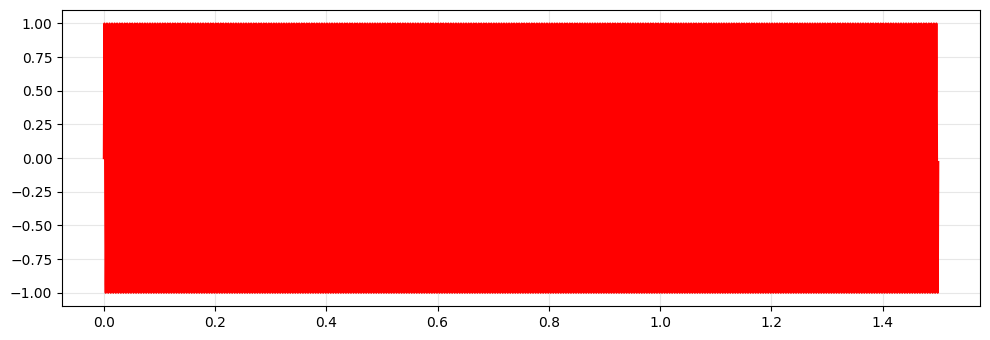

In [15]:
'''
Vetor de tempo
'''
n1 = np.arange(N1)     # vetor de amostras de x1
t1 = n1 / fs1          # t = n Ts = n / fs

'''
Plot
'''
SIGNALplot(x1, t1)

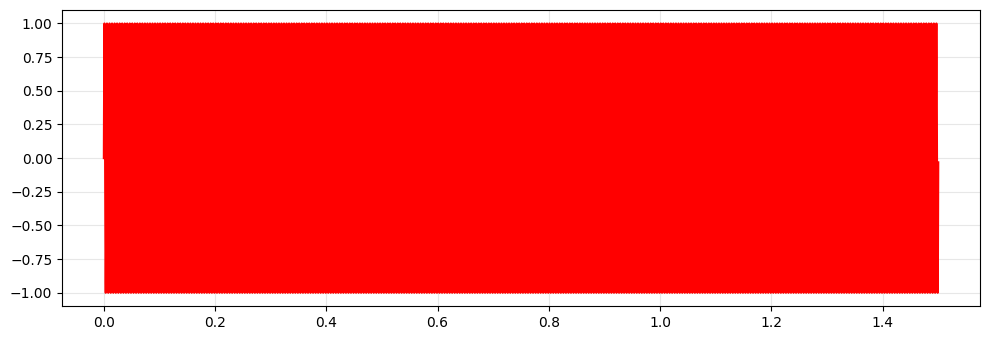

In [16]:
'''
Vetor de tempo
'''
t2 = n2 / fs2          # t = n Ts = n / fs

'''
Plot
'''
SIGNALplot(x2, t2)

<img src="./figures/sine_01.png" alt="" width="600"/>

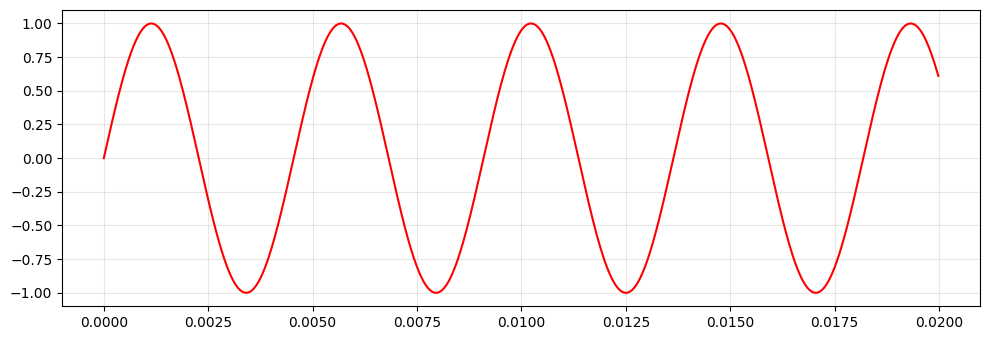

In [17]:
'''
Recorte
'''
r = int(0.02 * fs1)    # primeiros 20 ms do sinal (~4.4 periodos)

'''
Plot
'''
SIGNALplot(x1[:r], t1[:r])

<img src="./figures/sine_02.png" alt="" width="600"/>

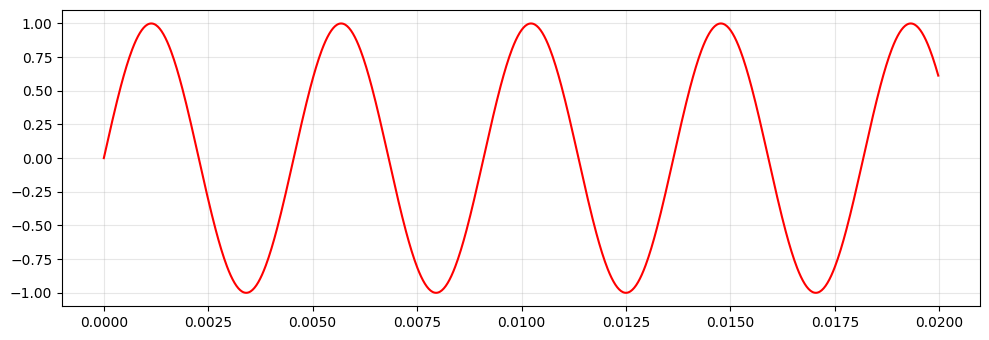

In [18]:
'''
Recorte
'''
r = int(0.02 * fs2)    # os mesmos 20 ms, agora com fs2

'''
Plot
'''
SIGNALplot(x2[:r], t2[:r])

**Observação:** no domínio do tempo os dois recortes de 20 ms mostram **exatamente o mesmo número de ciclos** ($0.02 \times 220 = 4.4$ períodos), porque $x_{1}$ e $x_{2}$ têm a mesma frequência. O que muda é o número de amostras usadas: $r_{1} = 960$ e $r_{2} = 882$.

Faça um novo recorte para plotar ***apenas*** 2.5 períodos de cada sinal.

***Dica:*** Verifique o resultado mostrando o **eixo horizontal** no "***domínio das amostras***".

<img src="./figures/sine_03.png" alt="" width="600"/>

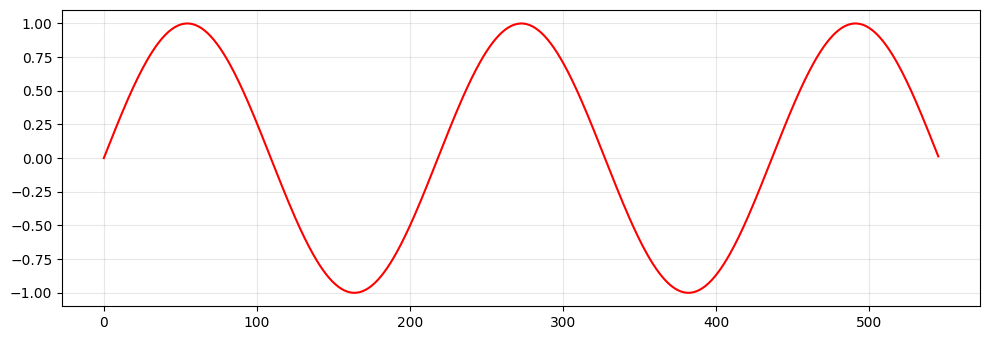

In [19]:
'''
Recorte
'''
r = int(np.ceil(2.5 * P1))    # 2.5 periodos de x1 -> 546 amostras

SIGNALplot(x1[:r], n1[:r])

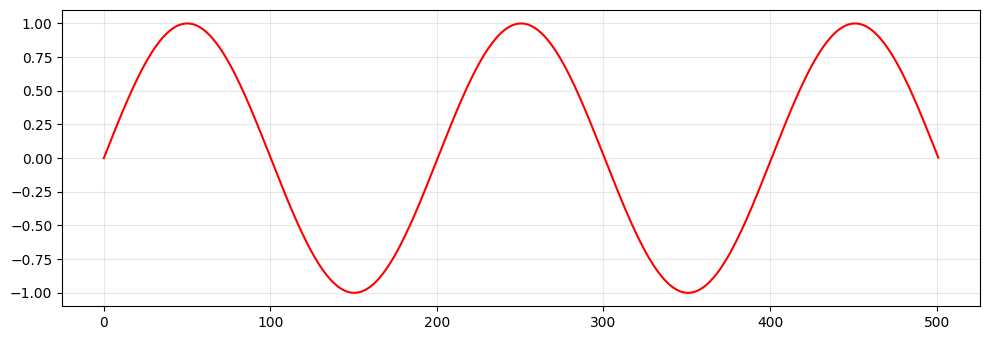

In [20]:
'''
Recorte
'''
r = int(np.ceil(2.5 * P2))    # 2.5 periodos de x2 -> 502 amostras

SIGNALplot(x2[:r], n2[:r])

**Observação:** no domínio das amostras, os mesmos 2.5 períodos ocupam $2.5\,P_{1} \approx 546$ amostras em $x_{1}$ e $2.5\,P_{2} \approx 502$ amostras em $x_{2}$. Como $f_{s_{2}} < f_{s_{1}}$, o sinal $x_{2}$ usa menos amostras por ciclo.

## Desafio

A partir da primitiva `SIGNALgenerate`, aumente a sua **biblioteca de processamento sinais** com a função `SIGNALtone`, que permita criar um ***tom*** controlado por ***frequencia*** e ***duração***.

In [21]:
def SIGNALtone(f=440.0, dur=1.0):
    '''
    Tone with predefined frequency and duration

    f  : Signal frequency (Hz)
    dur: Duration (s)

    x  : Output signal
    fs : Sampling freq. (CD standard by def.)
    '''

    fs = 44100 # Sampling freq. 

    N = int(dur * fs)   # d = N Ts
    P = fs / f          # f = fs / P

    x, _ = SIGNALgenerate(signal='osc', N=N, P=P)

    return x, fs

Teste a função para um sinal de 330 Hz com 3 segundos de duração.

In [22]:
f = 330.0 # signal freq (Hz)
dur = 3.0 # duration (s)

In [23]:
x, fs = SIGNALtone(f, dur)

In [24]:
play(x, fs)

## Revelando a "*velocidade*" dos sinais

Como comprovar que estamos gerando as frequências corretas?

***Dica:*** Estude a função `np.fft.fft` que permite evidenciar as "*velocidades*" de sinais. \
Use `SIGNALplot` para plotar a **magnitude** da FFT no domínio das amostras.

<img src="./figures/spec_01.png" alt="" width="600"/>

In [25]:
# help(np.fft.fft)

In [26]:
N = len(x)
k_pico = f * N / fs
print(f'N = {N}, pico esperado em k = {k_pico:.0f} e k = {N - k_pico:.0f}')

N = 132300, pico esperado em k = 990 e k = 131310


**Resposta:** usamos a **Transformada Discreta de Fourier (DFT)**, calculada de forma eficiente pela FFT (`np.fft.fft`):

$$
\Large
X[k] = \sum_{n=0}^{N-1} x[n] \, e^{-j \frac{2 \pi}{N} k n}, \quad k = 0, \dots, N-1
$$

A magnitude $|X[k]|$ mostra a quantidade de cada "*velocidade*" (frequência) presente no sinal. Um tom puro de frequência $f$ aparece como um **pico** no índice $k = f\,N/f_{s}$. Para o tom de 330 Hz com 3 s ($N = 132300$), o pico fica em $k = 990$. Há também um pico espelhado em $k = N - 990$, porque o sinal é real.

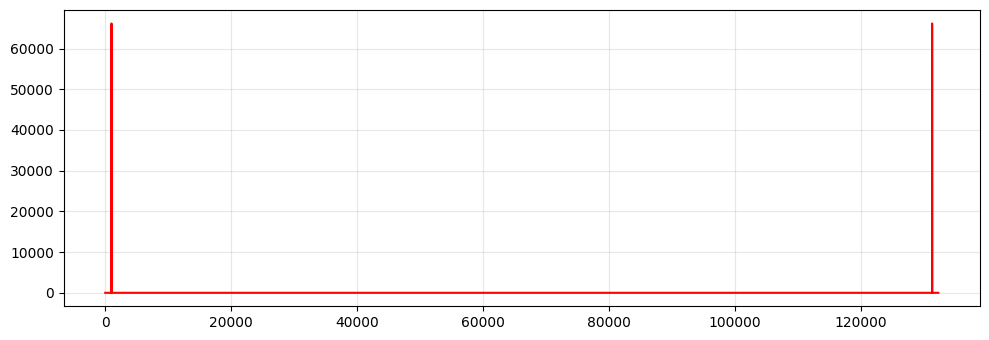

In [27]:
X    = np.fft.fft(x)        # espectro complexo
Xmag = np.abs(X)            # magnitude |X[k]|
n = np.arange(len(Xmag))    # indices das amostras do espectro

SIGNALplot(Xmag, n)

Aproveitando a ***simetria***, faça um recorte, apropriado, de apenas a metade das amostras.

<img src="./figures/spec_02.png" alt="" width="600"/>

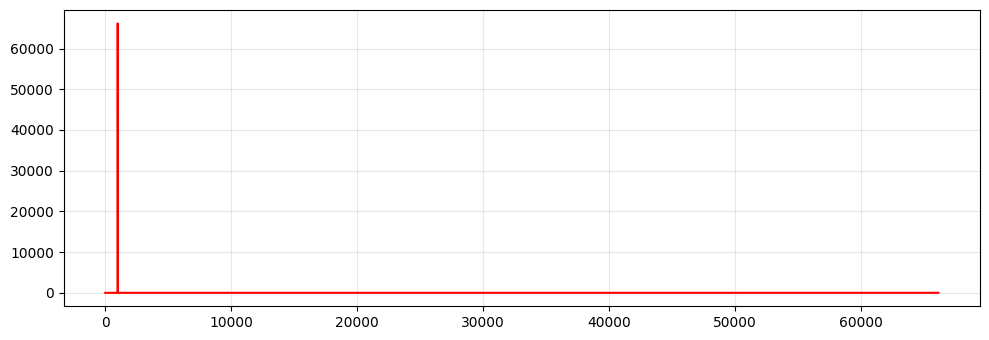

In [28]:
'''
Recorte no dominio das amostras
'''
r = len(Xmag) // 2    # metade do espectro (de 0 ate fs/2)

SIGNALplot(Xmag[:r], n[:r])

**Observação:** para sinais reais, $|X[k]| = |X[N-k]|$. A segunda metade do espectro é um espelho da primeira e não traz informação nova, por isso basta olhar as $N/2$ primeiras amostras (de $0$ até $f_{s}/2$, a frequência de Nyquist).

## Plotando as frequências

Agora vamos renomear o eixo horizontal para apresentar o sinal no "***domínio da frequência***":

$$
\Large
f = \frac{n}{N} f_{s}
$$

<img src="./figures/spec_03.png" alt="" width="600"/>

In [29]:
fHz = n / len(Xmag) * fs    # f = (n / N) fs

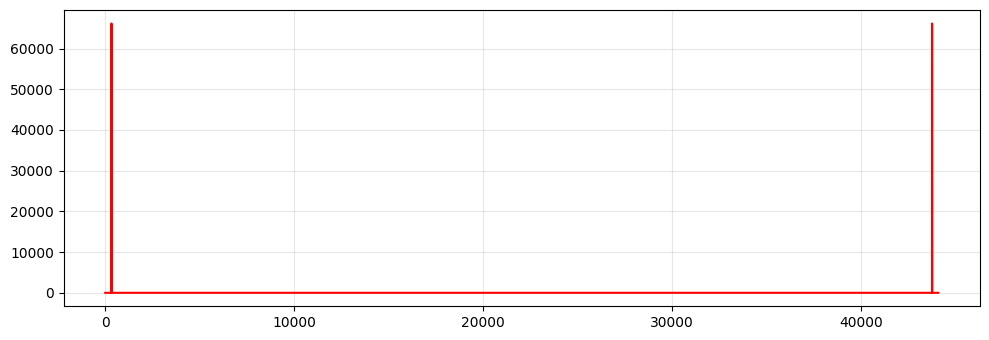

In [30]:
SIGNALplot(Xmag, fHz)

Aproveite o recorte anterior **no domínio das amostras** e aplique-o no sinal.

<img src="./figures/spec_04.png" alt="" width="600"/>

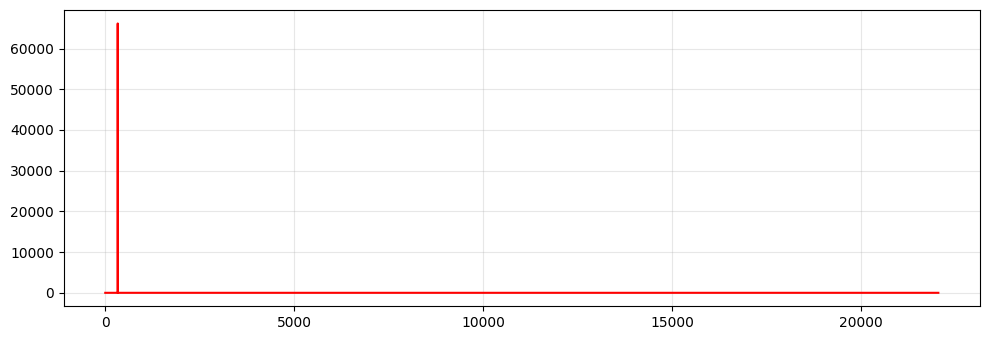

In [31]:
'''
Recorte no dominio das amostras
'''
r = len(Xmag) // 2    # mesmo recorte: metade das amostras (ate fs/2 = 22050 Hz)

SIGNALplot(Xmag[:r], fHz[:r])

Agora, aplique um recorte similar **no domínio das frequências**.

<img src="./figures/spec_05.png" alt="" width="600"/>

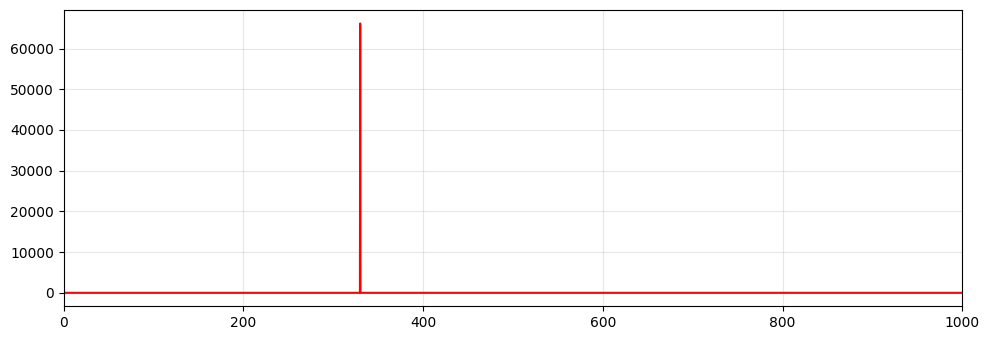

In [32]:
'''
Recorte no dominio das frequencias
'''
SIGNALplot(Xmag, fHz, \
           xlim=[0, 1000])

**Resultado:** o pico aparece exatamente em **330 Hz**, o que confirma que `SIGNALtone` gera a frequência pedida.

Plote a ***forma de onda*** e o ***espectro*** para um único sinal com frequencias de 200, 400, 600 e 800 Hz e 1 segundo de duração.

<img src="./figures/sine_04.png" alt="" width="600"/>

<img src="./figures/spec_06.png" alt="" width="600"/>

In [33]:
# Resposta
freqs = [200.0, 400.0, 600.0, 800.0]   
dur_x = 1.0                            

# Soma dos tons (normalizada para amplitude maxima 1)
x = 0
for fk in freqs:
    xk, fs_x = SIGNALtone(fk, dur_x)
    x = x + xk
x = x / len(freqs)

# Eixos de tempo e de frequencia
nx = np.arange(len(x))
tx = nx / fs_x                      

X      = np.fft.fft(x)
Xmag   = np.abs(X)
fHz_x  = nx / len(x) * fs_x         

In [34]:
play(x, fs_x)

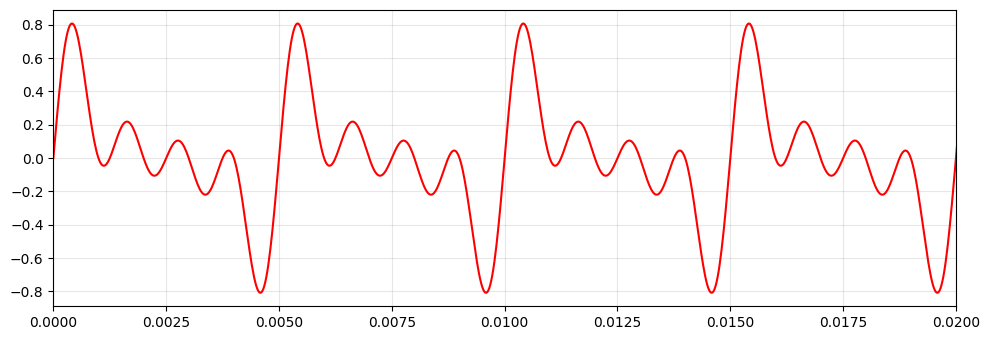

In [35]:
SIGNALplot(x, tx, \
          xlim=[0, 0.02])    # 20 ms = 4 periodos da fundamental (200 Hz)

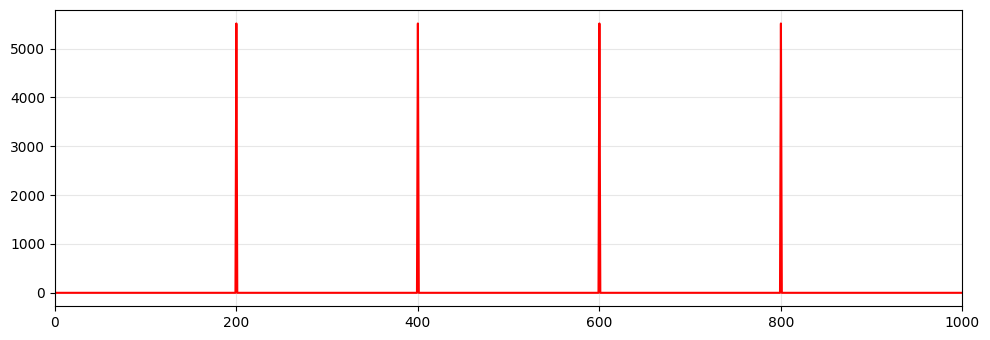

In [36]:
SIGNALplot(Xmag, fHz_x, \
           xlim=[0, 1000])

**Resultado:** a forma de onda não é mais uma senoide simples, mas continua **periódica**, com período $1/200 = 5$ ms, porque todas as componentes são múltiplas de 200 Hz. O espectro mostra **quatro picos** de mesma altura, em 200, 400, 600 e 800 Hz: a FFT separa cada "*velocidade*" presente na soma.

Oba! Agora sim conseguimos gerar e comprovar as frequencias, ou "*velocidades*", presentes nos sinais!

## Bonus track

A partir da primitiva `SIGNALgenerate`, aumente a sua **biblioteca de processamento sinais** com a função `SIGNALwaveform`, que admita ***tons*** com [***formas de onda*** (*waveforms*)](https://en.wikipedia.org/wiki/Waveform) aleatórias.

***Dica:*** Comece criando um sinal aleatório de tamanho igual a um período. Depois é apenas replicar o sinal até o tamanho final usando `np.concatenate`.

In [37]:
def SIGNALwaveform(f=440.0, dur=1.0):
    '''
    Tone with a random waveform as input

    f  : Signal frequency
    dur: Duration (seconds)

    x  : Output signal
    fs : Sampling freq. (CD standard by def.)
    '''

    fs = 44100 # Sampling freq. (CD standard)

    N = int(dur * fs)       # tamanho total
    P = int(round(fs / f))  # periodo em amostras (inteiro, para poder replicar)

    # Um unico periodo aleatorio (a "forma de onda")
    waveform, _ = SIGNALgenerate(signal='random', N=P, dist='uniform')
    waveform = waveform - np.mean(waveform)        # remove o nivel DC
    waveform = waveform / np.max(np.abs(waveform)) # amplitude maxima 1

    # Replica o periodo ate cobrir N amostras e corta o excesso
    reps = int(np.ceil(N / P))
    x = np.concatenate([waveform] * reps)[:N]

    return x, fs

Teste a função para um sinal de 110 Hz e 1 segundo de duração.

In [38]:
f = 110.0
dur = 1.0

y, fs = SIGNALwaveform(f, dur)

In [39]:
play(y, fs)

Verifique a frequencia do sinal gerado. \
O que achou de diferente nele?

<img src="./figures/spec_07.png" alt="" width="600"/>

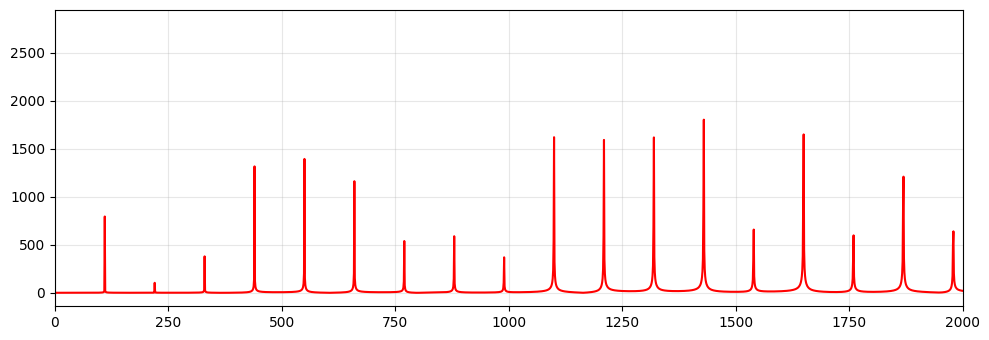

In [40]:
ny     = np.arange(len(y))
Ymag   = np.abs(np.fft.fft(y))
fHz_y  = ny / len(y) * fs           # f = (n / N) fs

SIGNALplot(Ymag, fHz_y, \
           xlim=[0, 2000])

**Resposta:** o som tem a **mesma altura** (*pitch*) de um tom de 110 Hz, mas o espectro **não tem um único pico**. Aparecem vários picos igualmente espaçados em $110, 220, 330, 440, \dots$ Hz, ou seja, uma **série harmônica** com frequências $k \cdot f_{0}$.

- A **fundamental** $f_{0} = f_{s}/P = 44100/401 \approx 110$ Hz vem da repetição do período. Como o período precisa ser um número inteiro de amostras ($P = 401$), a frequência real é $\approx 109.98$ Hz.
- As **amplitudes dos harmônicos são aleatórias**, porque dependem da forma de onda sorteada. Elas definem o **timbre**: cada execução produz um som diferente, mas com a mesma nota. Como o ruído tem energia em todas as frequências, os harmônicos se estendem até $f_{s}/2$. O gráfico mostra só até 2 kHz; o pico mais alto pode estar fora dessa janela.

Qualquer sinal periódico que não seja senoidal é uma soma de senoides harmônicas (série de Fourier). O ruído aleatório, que sozinho soaria como um chiado, passa a soar como uma nota quando o repetimos periodicamente. Essa é a base da síntese de Karplus-Strong.

Plote apenas 5 períodos do sinal.

<img src="./figures/signal_01.png" alt="" width="600"/>

In [41]:
P = int(round(fs / f))   # periodo em amostras 
print(P)

401


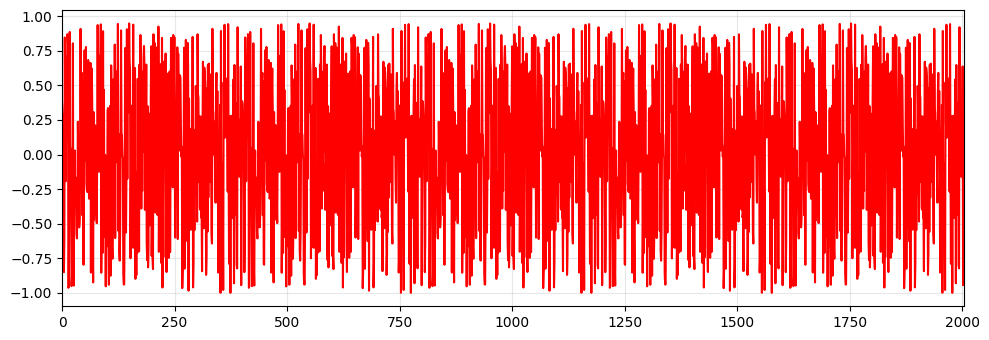

In [42]:
SIGNALplot(y, ny, \
           xlim=[0, 5 * P])

**Observação:** o gráfico mostra o mesmo trecho aleatório de $P = 401$ amostras repetido 5 vezes, e é essa repetição que dá a frequência de 110 Hz.

Pronto! Agora estamos preparados para analisar sinais no ***domínio da frequência!***